# African Credit Scoring — Decision Trees & Ensemble Practice

This notebook is a simplified practice of the concepts from the *Decision Trees* lesson.  
We use the African Credit Scoring Challenge as a real-world application.

**Goal:** Predict loan default (`Target = 1`) using a **LightGBM** model (gradient boosting).

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
print('Setup done ✅')

Setup done ✅


## 1. Load Data

In [2]:
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (68654, 16)
Test shape:  (18594, 15)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0


## 2. Preprocessing

Decision trees (and LightGBM) handle most data types natively — they don't need feature scaling (no standardization needed, unlike linear models).  
We just need to:
- Parse dates and extract useful numbers from them
- Encode categorical features as integers
- Handle missing values

In [ ]:
TARGET = 'target'   
ID     = 'ID'

y         = train[TARGET].copy()
test_ids  = test[ID].copy()

train_df = train.drop(columns=[TARGET, ID])
test_df  = test.drop(columns=[ID])

# Combine for consistent preprocessing
n_train = len(train_df)
df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# Parse dates
for col in df.select_dtypes(include='object').columns:
    try:
        parsed = pd.to_datetime(df[col], errors='raise')
        df[col + '_year']  = parsed.dt.year
        df[col + '_month'] = parsed.dt.month
        df[col + '_day']   = parsed.dt.day
        df = df.drop(columns=[col])
    except Exception:
        pass  # not a date column

# Encode remaining categoricals
from sklearn.preprocessing import LabelEncoder
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Fill any remaining NaNs
df = df.fillna(df.median(numeric_only=True))

X_train = df.iloc[:n_train]
X_test  = df.iloc[n_train:]

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (68654, 18), X_test: (18594, 18)


## 3. Why LightGBM?

From the lesson:

- A single **decision tree** splits the input space recursively. It is easy to interpret but **unstable** and **not very accurate** on its own.
- **Boosting** (covered in the last section of the lesson) builds an additive model: each new tree corrects the residual errors of the previous ones.
- **LightGBM** is an implementation of **gradient boosting** — it fits weak learners (shallow trees) sequentially, minimizing a loss function via gradient descent.
- Unlike bagging/random forests which reduce variance, boosting primarily **reduces bias**, making it very powerful on structured data.

The key hyperparameters we set:
- `n_estimators`: number of trees M in the additive model
- `learning_rate` (ν): the shrinkage factor that controls update size
- `num_leaves` / `max_depth`: controls tree complexity (regularization)
- `scale_pos_weight`: handles class imbalance by weighting the positive class

In [4]:
# Class imbalance
neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos_weight = neg / pos
print(f'Class 0: {neg}  |  Class 1: {pos}  |  scale_pos_weight: {scale_pos_weight:.1f}')

Class 0: 67396  |  Class 1: 1258  |  scale_pos_weight: 53.6


## 4. Training with Cross-Validation

We use **StratifiedKFold** (5 folds) to evaluate the model while keeping the class ratio balanced in each fold.  
We also search for the best **decision threshold** (not always 0.5) to maximize the F1-Score, since the dataset is highly imbalanced.

In [5]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    verbose=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
f1_scores  = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model.fit(X_tr, y_tr)

    val_proba = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_proba
    test_preds += model.predict_proba(X_test)[:, 1] / 5

    # Find best threshold for F1
    thresholds = np.linspace(0.01, 0.99, 200)
    f1s = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
    best_thresh = thresholds[np.argmax(f1s)]
    best_f1 = max(f1s)
    f1_scores.append(best_f1)

    print(f'Fold {fold+1}/5 — F1: {best_f1:.4f}  (threshold: {best_thresh:.2f})')

print(f'\nMean CV F1: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}')

Fold 1/5 — F1: 0.7992  (threshold: 0.29)
Fold 2/5 — F1: 0.8412  (threshold: 0.57)
Fold 3/5 — F1: 0.8199  (threshold: 0.37)
Fold 4/5 — F1: 0.8201  (threshold: 0.16)
Fold 5/5 — F1: 0.8081  (threshold: 0.27)

Mean CV F1: 0.8177 ± 0.0141


## 5. Feature Importance

One advantage of tree-based models mentioned in the lesson: **automatic variable selection**.  
We can inspect which features the model used most for its splits.

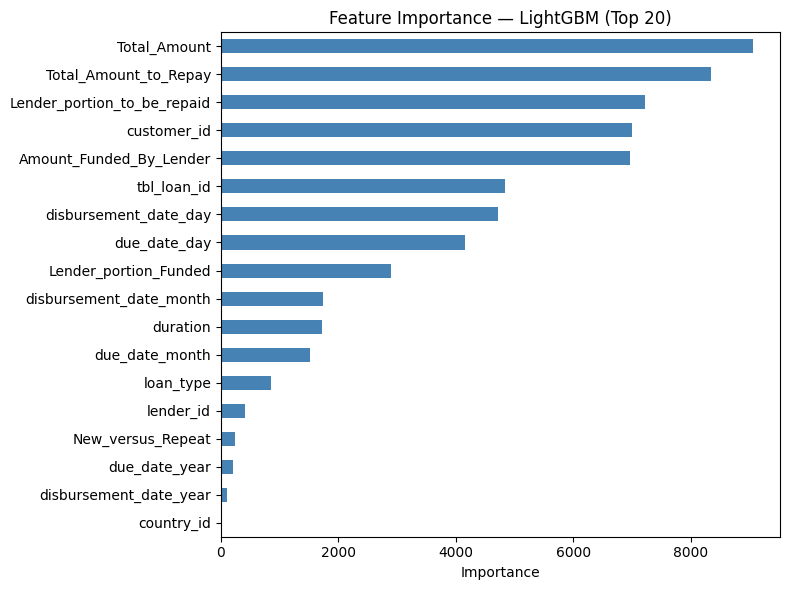

In [6]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Feature Importance — LightGBM (Top 20)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Submission

In [7]:
# Global best threshold on full OOF predictions
thresholds = np.linspace(0.01, 0.99, 200)
f1s = [f1_score(y, (oof_preds >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1s)]
print(f'Global best threshold: {best_thresh:.3f}  —  OOF F1: {max(f1s):.4f}')

final_preds = (test_preds >= best_thresh).astype(int)

submission = pd.DataFrame({'ID': test_ids, 'Target': final_preds})
submission.to_csv('submission.csv', index=False)
print('\nSubmission saved ✅')
submission.head()

Global best threshold: 0.301  —  OOF F1: 0.8142

Submission saved ✅


,ID,Target
0,ID_269404226088267278,0
1,ID_255356300042267278,0
2,ID_257026243764267278,0
3,ID_264617299409267278,0
4,ID_247613296713267278,0
